In [44]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np

In [45]:
# Names from json file:
names_json = ["SM","cQu8","ctu8","cQu1","ctd8","cQlMi","cpQ3","ctlTi","ctG","ctZ","ctW","ctli","ctb8","cbW","cQl3i","cQq13",
              "cptb","ctp","ctei","cpQM","ctlSi", "cQq83","cQq81","ctq1","ctu1","cQei","cQb8","cpt","ctq8","cQd1","cQq11",
              "cQd8","ctd1"]

# All 561 combinations of coefficients (i.e SM,SM; SM,cQu8; cQu8,cQu8; SM,ctu8; cQu8,ctu8; ...)
name_combinations = []
for i in range(len(names_json)):
    for a in range(i+1):
        name_combinations.append([names_json[i],names_json[a]])

In [46]:
# Open file
file = uproot.open("sample_root_files/ttH_output_919.root")
# Open events tree
events_tree = file['Events']
# Open EFTFitCoefficients branch:
eft_coeff = events_tree['EFTfitCoefficients'].array()

In [47]:
# Making function that adds weights to the histograms below
def weights(data):
    return [1 / len(data)] * len(data)

In [48]:
elec_n = events_tree['nElectron'].array()
mu_n = events_tree['nMuon'].array()
tau_n = events_tree['nTau'].array()

In [49]:
lepton_n = elec_n + mu_n + tau_n
tri_lepton = lepton_n == 3

In [50]:
eft_coeff_tri_lepton = []
for i,n in enumerate(tri_lepton):                                       
    if n == True:
        eft_coeff_tri_lepton.append(np.argmax(np.abs(eft_coeff[i,1:])) + 1)

In [51]:
def interesting_coeff(data, percent_min, percent_max):
    percent_and_index = []
    
    for i in range(561):
        coeff_percentage = data.count(i) / len(data)
        if percent_min == percent_max: # Just to avoid errors if we are trying to find a specific percentage
            if coeff_percentage == percent_min:
               percent_and_index.append([round(coeff_percentage*100,7), i]) 
        elif (coeff_percentage > percent_min) and (coeff_percentage <= percent_max): # finds values such that percent_min < value <= percent_max
            percent_and_index.append([round(coeff_percentage*100,7), i])
    
           
    percent_and_index = np.array(percent_and_index)
    indices = np.argsort(percent_and_index[:,0])                    # This tells me the order of the rows
    percent_and_index_ordered = percent_and_index[indices][::-1] # This sorts the rows based on the indices and [::-1] makes it go in descending order
    
    for i in range(len(percent_and_index_ordered)):
        a = print(f'The pair {name_combinations[int(percent_and_index_ordered[i,1])]} with index {int(percent_and_index_ordered[i,1])} has {percent_and_index_ordered[i,0]}%')

    return a

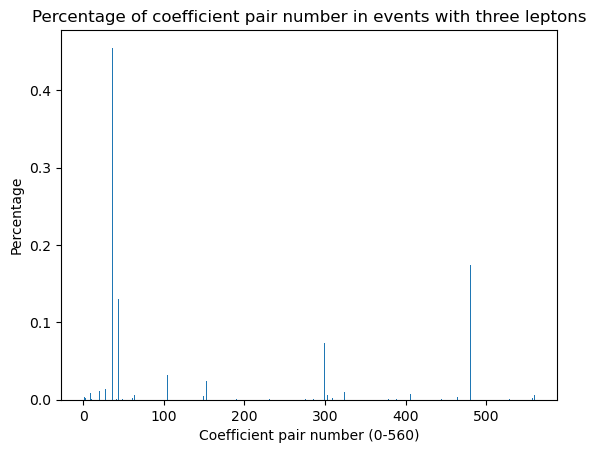

The pair ['ctG', 'SM'] with index 36 has 45.5255255%
The pair ['cQq11', 'cQq13'] with index 480 has 17.4774775%
The pair ['ctG', 'ctG'] with index 44 has 12.972973%
The pair ['ctq1', 'ctq1'] with index 299 has 7.3873874%


1665

In [52]:
plt.hist(eft_coeff_tri_lepton, bins = 500, weights = weights(eft_coeff_tri_lepton))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number in events with three leptons')
plt.show()
interesting_coeff(eft_coeff_tri_lepton,0.05,1)
len(eft_coeff_tri_lepton)

In [53]:
elec_charge = events_tree['Electron_charge'].array()
mu_charge = events_tree['Muon_charge'].array()
tau_charge = events_tree['Tau_charge'].array()

In [54]:
def two_leptons_same_charge(data_n, data_charge):
    events_two_leptons_same_charge = []
    
    for i,n in enumerate(data_n == 2):
        if n == True:
            if (np.count_nonzero(data_charge[i] == 1) == 2) or (np.count_nonzero(data_charge[i] == -1) == 2):
                events_two_leptons_same_charge.append(i)
    return events_two_leptons_same_charge

In [55]:
all_events_with_two_leptons_same_charge = list(set(two_leptons_same_charge(elec_n, elec_charge) + 
                                                   two_leptons_same_charge(mu_n, mu_charge) + 
                                                   two_leptons_same_charge(tau_n, tau_charge)))

In [56]:
eft_coeff_same_charge_leptons = []
for i, n in enumerate(all_events_with_two_leptons_same_charge):
    eft_coeff_same_charge_leptons.append(np.argmax(np.abs(eft_coeff[n,1:])) + 1)

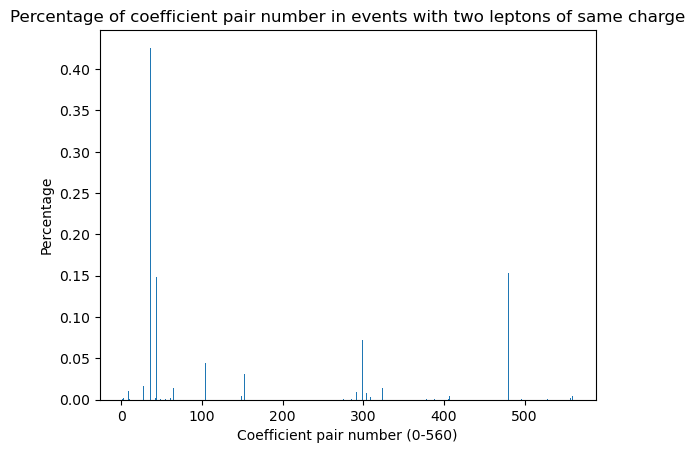

The pair ['ctG', 'SM'] with index 36 has 42.5929466%
The pair ['cQq11', 'cQq13'] with index 480 has 15.3684412%
The pair ['ctG', 'ctG'] with index 44 has 14.7949919%
The pair ['ctq1', 'ctq1'] with index 299 has 7.2397974%


20926

In [57]:
plt.hist(eft_coeff_same_charge_leptons, bins = 500, weights = weights(eft_coeff_same_charge_leptons))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number in events with two leptons of same charge')
plt.show()
interesting_coeff(eft_coeff_same_charge_leptons,0.05,1)
len(eft_coeff_same_charge_leptons)

In [58]:
def two_leptons_opposite_charge(data_n, data_charge):
    events_two_leptons_opposite_charge = []
    
    for i,n in enumerate(data_n == 2):
        if n == True:
            if (np.count_nonzero(data_charge[i] == 1) == 1) and (np.count_nonzero(data_charge[i] == -1) == 1):
                events_two_leptons_opposite_charge.append(i)
    return events_two_leptons_opposite_charge

In [59]:
all_events_with_two_leptons_opposite_charge = list(set(two_leptons_opposite_charge(elec_n, elec_charge) + 
                                                       two_leptons_opposite_charge(mu_n, mu_charge) + 
                                                       two_leptons_opposite_charge(tau_n, tau_charge)))
# This line works because the outputs are lists. If they were numpy arrays, they would actually add! We would need to use concatenate.

In [60]:
eft_coeff_opposite_charge_leptons = []
for i, n in enumerate(all_events_with_two_leptons_opposite_charge):
    eft_coeff_opposite_charge_leptons.append(np.argmax(np.abs(eft_coeff[n,1:])) + 1)

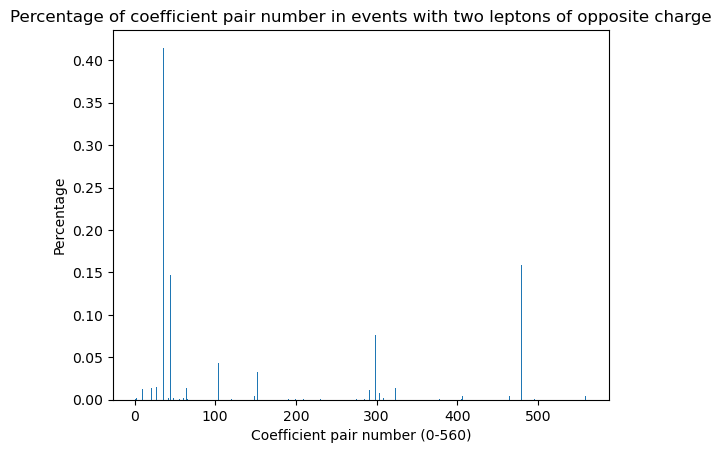

The pair ['ctG', 'SM'] with index 36 has 41.4739277%
The pair ['cQq11', 'cQq13'] with index 480 has 15.8746846%
The pair ['ctG', 'ctG'] with index 44 has 14.7077376%
The pair ['ctq1', 'ctq1'] with index 299 has 7.6429773%


19024

In [61]:
plt.hist(eft_coeff_opposite_charge_leptons, bins = 500, weights = weights(eft_coeff_opposite_charge_leptons))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number in events with two leptons of opposite charge')
plt.show()
interesting_coeff(eft_coeff_opposite_charge_leptons,0.05,1)
len(eft_coeff_opposite_charge_leptons)

In [62]:
all_events_tri_lepton = []
for i, n in enumerate(lepton_n):
    if n == 3:
        all_events_tri_lepton.append(i)

In [63]:
def mean_and_median(data):
    mean = []
    median = []

    eft_coeff_for_data = []
    for event in data:
        eft_coeff_for_data.append(eft_coeff[event])
    eft_coeff_for_data = np.array(eft_coeff_for_data)

    for i in range(561):
        mean.append(np.mean(np.abs(eft_coeff_for_data[:,i])))
        median.append(np.median(np.abs(eft_coeff_for_data[:,i])))

    return mean, median

def interesting_mean(data):
    index_and_mean = []
    for i,n in enumerate(data):
        if abs(n) > 0.0005:
            index_and_mean.append([i, abs(n)])
            
    index_and_mean = np.array(index_and_mean)
    order = np.argsort(index_and_mean[:,1])
    index_and_mean_ordered = index_and_mean[order][::-1]
    
    print('The following indices have a MEAN higher than 0.0005')
    
    for i in range(len(index_and_mean_ordered)):
       a = print(f'\n Index: {index_and_mean_ordered[i,0]} ({name_combinations[int(index_and_mean_ordered[i,0])]}) has mean {np.round(index_and_mean_ordered[i,1], decimals = 7)}')
    return a

def interesting_median(data):
    index_and_median = []
    for i,n in enumerate(data):
        if abs(n) > 0.0001:
            index_and_median.append([i, abs(n)])
            
    index_and_median = np.array(index_and_median)
    order = np.argsort(index_and_median[:,1])
    index_and_median_ordered = index_and_median[order][::-1]
    
    print('The following indices have a MEDIAN higher than 0.0001')
    
    for i in range(len(index_and_median_ordered)):
        a = print(f'\n Index: {index_and_median_ordered[i,0]} ({name_combinations[int(index_and_median_ordered[i,0])]}) has median {np.round(index_and_median_ordered[i,1], decimals = 6)}')
    return a

In [64]:
mean_for_tri_leptons, median_for_tri_leptons = mean_and_median(all_events_tri_lepton)
mean_for_two_leptons_same_charge, median_for_two_leptons_same_charge = mean_and_median(all_events_with_two_leptons_same_charge)
mean_for_two_leptons_opposite_charge, median_for_two_leptons_opposite_charge = mean_and_median(all_events_with_two_leptons_opposite_charge)

In [65]:
def plotting(mean, median, data):
    coeffs = np.arange(0,561)

    plt.bar(coeffs, mean, width = 2)
    plt.xlabel('Coefficient-pair number')
    plt.ylabel('Mean value')
    plt.title(f'Mean value of coefficient-pairs of events with {data}')
    #plt.yscale('log')
    plt.show()
    
    interesting_val1 = interesting_mean(mean)
    
    plt.bar(coeffs, median, width = 2, color = 'orange')
    plt.xlabel('Coefficient-pair number')
    plt.ylabel('Median value')
    plt.title(f'Median value of coefficient-pairs of events with {data}')
    #plt.yscale('log')
    plt.show()
    
    interesting_val2 = interesting_median(median)
    return (plt.show(), interesting_val1, interesting_val2)

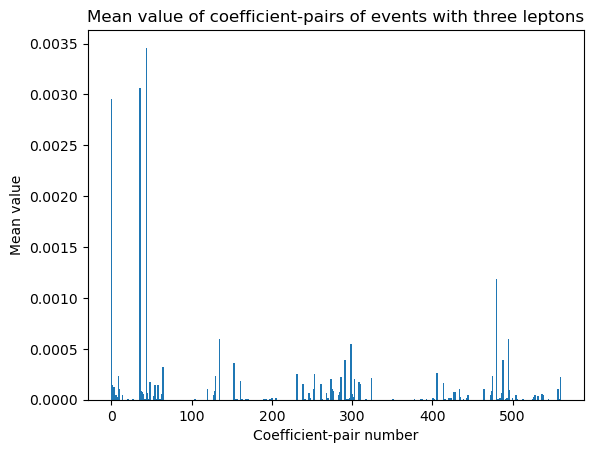

The following indices have a MEAN higher than 0.0005

 Index: 44.0 (['ctG', 'ctG']) has mean 0.0034598

 Index: 36.0 (['ctG', 'SM']) has mean 0.0030675

 Index: 0.0 (['SM', 'SM']) has mean 0.0029523

 Index: 480.0 (['cQq11', 'cQq13']) has mean 0.0011866

 Index: 135.0 (['cQq13', 'cQq13']) has mean 0.0005936

 Index: 495.0 (['cQq11', 'cQq11']) has mean 0.0005936

 Index: 299.0 (['ctq1', 'ctq1']) has mean 0.0005499


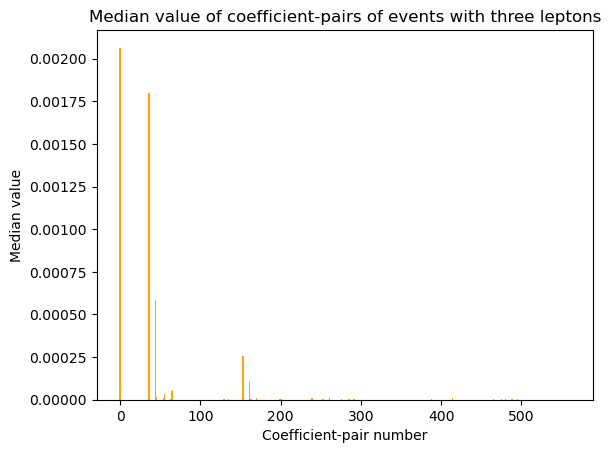

The following indices have a MEDIAN higher than 0.0001

 Index: 0.0 (['SM', 'SM']) has median 0.002064

 Index: 36.0 (['ctG', 'SM']) has median 0.001797

 Index: 44.0 (['ctG', 'ctG']) has median 0.000586

 Index: 153.0 (['ctp', 'SM']) has median 0.000254

 Index: 161.0 (['ctp', 'ctG']) has median 0.000108


In [66]:
plotting(mean_for_tri_leptons, median_for_tri_leptons, 'three leptons')
plt.show()

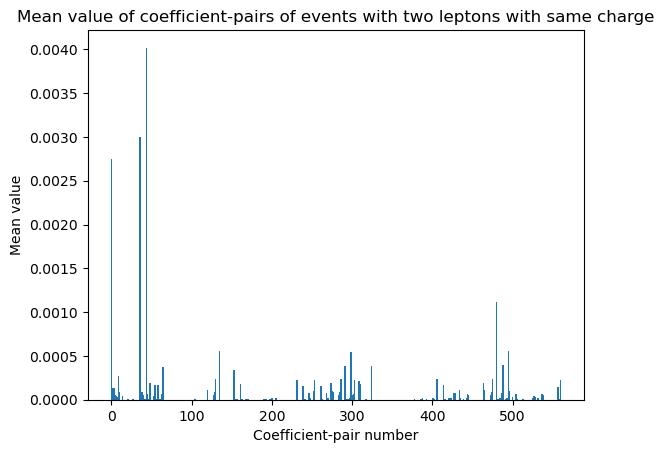

The following indices have a MEAN higher than 0.0005

 Index: 44.0 (['ctG', 'ctG']) has mean 0.0040192

 Index: 36.0 (['ctG', 'SM']) has mean 0.0029973

 Index: 0.0 (['SM', 'SM']) has mean 0.0027503

 Index: 480.0 (['cQq11', 'cQq13']) has mean 0.0011208

 Index: 135.0 (['cQq13', 'cQq13']) has mean 0.000561

 Index: 495.0 (['cQq11', 'cQq11']) has mean 0.0005609

 Index: 299.0 (['ctq1', 'ctq1']) has mean 0.0005497


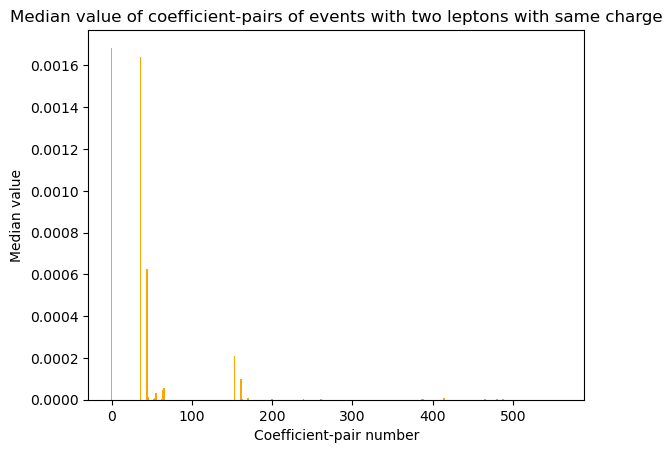

The following indices have a MEDIAN higher than 0.0001

 Index: 0.0 (['SM', 'SM']) has median 0.001685

 Index: 36.0 (['ctG', 'SM']) has median 0.001641

 Index: 44.0 (['ctG', 'ctG']) has median 0.000625

 Index: 153.0 (['ctp', 'SM']) has median 0.000209


In [67]:
plotting(mean_for_two_leptons_same_charge, median_for_two_leptons_same_charge, 'two leptons with same charge')
plt.show()

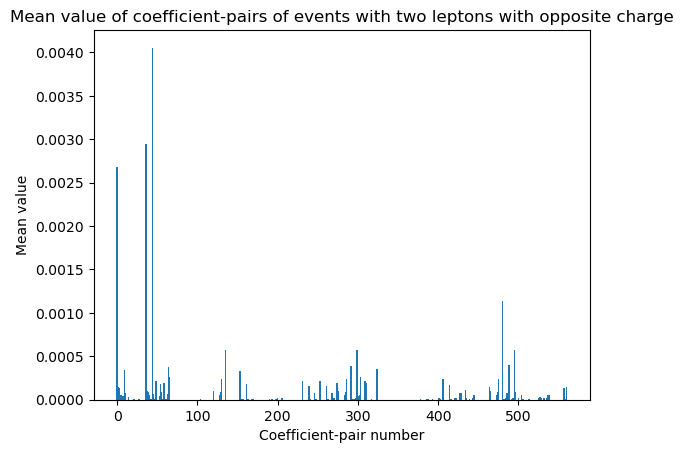

The following indices have a MEAN higher than 0.0005

 Index: 44.0 (['ctG', 'ctG']) has mean 0.0040544

 Index: 36.0 (['ctG', 'SM']) has mean 0.0029477

 Index: 0.0 (['SM', 'SM']) has mean 0.0026772

 Index: 480.0 (['cQq11', 'cQq13']) has mean 0.0011404

 Index: 135.0 (['cQq13', 'cQq13']) has mean 0.0005708

 Index: 495.0 (['cQq11', 'cQq11']) has mean 0.0005706

 Index: 299.0 (['ctq1', 'ctq1']) has mean 0.0005692


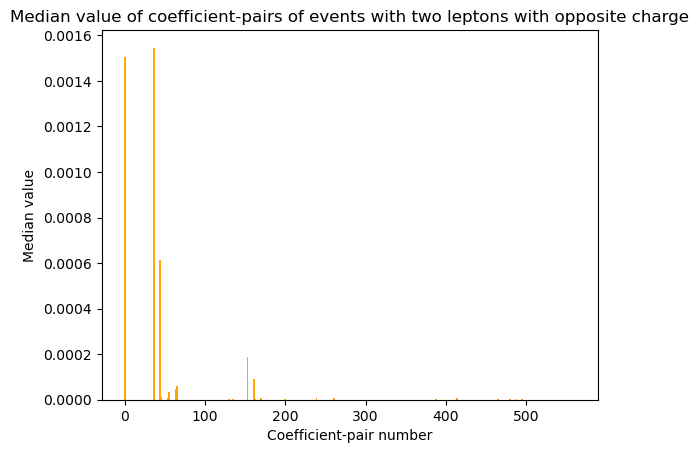

The following indices have a MEDIAN higher than 0.0001

 Index: 36.0 (['ctG', 'SM']) has median 0.001546

 Index: 0.0 (['SM', 'SM']) has median 0.001507

 Index: 44.0 (['ctG', 'ctG']) has median 0.000613

 Index: 153.0 (['ctp', 'SM']) has median 0.000189


In [68]:
plotting(mean_for_two_leptons_opposite_charge, median_for_two_leptons_opposite_charge, 'two leptons with opposite charge')
plt.show()